# Gamma PCA Statistical Factor Model

Clean implementation of the statistical factor model with optional idiosyncratic-volatility rescaling. Set `GAMMA = 0.0` for the no-idio model and `GAMMA = 1.0` for full idio-vol rescaling.

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from scipy.sparse.linalg import svds
from tqdm import tqdm

pd.set_option("display.max_columns", 100)


In [92]:
# Configuration
RETURNS_PATH = "Data/daily_returns_SPX.h5"
OUTPUT_DIR = "Data/Statistical_loadings"

N_FACTORS = 10
WINDOW_CORR = 800
CORR_HALF_LIFE = 200
WINDOW_IDIO = 600
IDIO_HALF_LIFE = 150
N_IDIO_FACTORS = 10
TOTAL_RETURN_RESCALING = True
# 0.0 = no idio scaling, 1.0 = full idio scaling, values in between are partial scaling.
GAMMA = 1.0

START_T = WINDOW_CORR - 1
END_T = None  # None means returns.shape[0] - 1
SAVE_OUTPUTS = False


In [93]:
returns = pd.read_hdf(RETURNS_PATH)
returns = returns.apply(pd.to_numeric)
returns = returns.sort_index()

if END_T is None:
    END_T = returns.shape[0] - 1

assert START_T >= WINDOW_CORR - 1
assert END_T <= returns.shape[0] - 1
returns.shape, returns.index[START_T], returns.index[END_T]


((2514, 428),
 Timestamp('2019-05-13 00:00:00'),
 Timestamp('2026-03-09 00:00:00'))

## Helpers

In [94]:
def exponential_weights(window, half_life):
    tau = half_life / np.log(2)
    kappa = np.sqrt(window * (1 - np.exp(-2 / tau)) / (1 - np.exp(-2 * window / tau)))
    return kappa * np.exp(-np.arange(window)[::-1] / tau)


def sort_svd(U, S, Vt):
    idx = np.argsort(S)[::-1]
    return U[:, idx], S[idx], Vt[idx, :]


def normalize_columns(X):
    norms = np.linalg.norm(X, axis=0)
    if np.any(norms == 0):
        raise ValueError("Cannot match factors with a zero-norm column")
    return X / norms


def orient_svd_deterministic(U, S, Vt, match_current=None):
    U = U.copy()
    S = S.copy()
    Vt = Vt.copy()
    basis = U if match_current is None else match_current

    for j in range(U.shape[1]):
        anchor = np.argmax(np.abs(basis[:, j]))
        if basis[anchor, j] < 0:
            U[:, j] *= -1
            Vt[j, :] *= -1

    diagnostics = {
        "current_rank_for_label": np.arange(U.shape[1]),
        "matched_abs_overlap": np.ones(U.shape[1]),
        "overlap_matrix": np.eye(U.shape[1]),
    }
    return U, S, Vt, diagnostics


def align_svd_to_previous(U, S, Vt, match_current=None, match_prev=None):
    U = U.copy()
    S = S.copy()
    Vt = Vt.copy()
    k = U.shape[1]
    current_basis = U if match_current is None else match_current

    if match_prev is None:
        return orient_svd_deterministic(U, S, Vt, current_basis)

    if match_prev.shape != current_basis.shape:
        raise ValueError(
            f"Previous matching basis shape {match_prev.shape} does not match current shape {current_basis.shape}"
        )

    previous_basis = normalize_columns(match_prev)
    current_basis = normalize_columns(current_basis)
    overlap = previous_basis.T @ current_basis
    rows, cols = linear_sum_assignment(-np.abs(overlap))

    U_aligned = np.empty_like(U)
    S_aligned = np.empty_like(S)
    Vt_aligned = np.empty_like(Vt)
    current_rank_for_label = np.empty(k, dtype=int)
    matched_abs_overlap = np.empty(k)

    for prev_label, current_rank in zip(rows, cols):
        sign = 1.0 if overlap[prev_label, current_rank] >= 0 else -1.0
        U_aligned[:, prev_label] = sign * U[:, current_rank]
        S_aligned[prev_label] = S[current_rank]
        Vt_aligned[prev_label, :] = sign * Vt[current_rank, :]
        current_rank_for_label[prev_label] = current_rank
        matched_abs_overlap[prev_label] = abs(overlap[prev_label, current_rank])

    diagnostics = {
        "current_rank_for_label": current_rank_for_label,
        "matched_abs_overlap": matched_abs_overlap,
        "overlap_matrix": np.abs(overlap),
    }
    return U_aligned, S_aligned, Vt_aligned, diagnostics


In [99]:
def estimate_current_idio_vols(
    returns,
    t,
    window_idio=WINDOW_IDIO,
    idio_half_life=IDIO_HALF_LIFE,
    n_idio_factors=N_IDIO_FACTORS,
):
    assert window_idio - 1 <= t < returns.shape[0]

    weights = exponential_weights(window_idio, idio_half_life)
    R_window = returns.iloc[t - window_idio + 1:t + 1, :].T.values
    R_weighted = R_window @ np.diag(weights)

    U, S, Vt = svds(R_weighted, k=n_idio_factors)
    U, S, Vt = sort_svd(U, S, Vt)

    residuals = R_weighted - U @ np.diag(S) @ Vt
    idio_vols = np.sqrt(np.mean(residuals**2, axis=1))
    floor = 1e-8
    return np.maximum(idio_vols, floor)


def estimate_current_model(
    returns,
    t,
    gamma=GAMMA,
    B_prev=None,
    window_corr=WINDOW_CORR,
    corr_half_life=CORR_HALF_LIFE,
    n_factors=N_FACTORS,
):
    assert window_corr - 1 <= t < returns.shape[0] - 1

    if gamma == 0:
        idio_vols = np.ones(returns.shape[1])
    elif TOTAL_RETURN_RESCALING:
        weights = exponential_weights(window_corr, corr_half_life)
        R_window = returns.iloc[t - window_corr + 1:t + 1, :].T.values  # (N, T)
        idio_vols = np.sqrt((R_window**2) @ (weights / weights.sum()))
    else:
        idio_vols = estimate_current_idio_vols(returns, t)
    
    W_time = np.diag(exponential_weights(window_corr, corr_half_life))
    scale = idio_vols ** gamma
    W_sigma = np.diag(1 / scale)

    R_window = returns.iloc[t - window_corr + 1:t + 1, :].T.values
    R_scaled = W_sigma @ R_window @ W_time

    U, S, Vt = svds(R_scaled, k=n_factors)
    U, S, Vt = sort_svd(U, S, Vt)
    B_ranked = np.diag(scale) @ U
    U, S, Vt, align_diag = align_svd_to_previous(
        U,
        S,
        Vt,
        match_current=B_ranked,
        match_prev=B_prev,
    )

    B = np.diag(scale) @ U
    next_returns_window = returns.iloc[t - window_corr + 2:t + 2, :].T.values
    next_return = next_returns_window[:, -1]
    factor_window = U.T @ W_sigma @ next_returns_window
    f_t = factor_window[:, -1]
    resid = next_return - B @ f_t

    return {
        "B": B,
        "U": U,
        "S": S,
        "f_t": f_t,
        "resid": resid,
        "idio_vols": idio_vols,
        "scale": scale,
        "align_diag": None
    }


## Rolling Model

In [100]:
models = {}
B_prev = None
prev_f_t = None
prev_resid = None

for t in tqdm(range(START_T, END_T)):
    models[t] = {
        "f_t": prev_f_t,
        "resid": prev_resid,
    }

    current = estimate_current_model(
        returns,
        t,
        gamma=GAMMA,
        B_prev=B_prev,
    )
    models[t].update({k: current[k] for k in ["B", "U", "S", "idio_vols", "scale", "align_diag"]})

    prev_f_t = current["f_t"]
    prev_resid = current["resid"]
    B_prev = current["B"]

len(models)


100%|██████████| 1714/1714 [00:41<00:00, 41.53it/s]


1714

## Dataframes

In [ ]:
factor_index = returns.index[START_T + 1:END_T]
model_index = returns.index[START_T:END_T]
tickers = returns.columns
factor_columns = [f"Factor {i}" for i in range(1, N_FACTORS + 1)]
carac_columns = [f"Carac {i}" for i in range(1, N_FACTORS + 1)]

factors = pd.DataFrame(
    np.array([models[t]["f_t"] for t in range(START_T + 1, END_T)]),
    index=factor_index,
    columns=factor_columns,
)

carac_index = pd.MultiIndex.from_product(
    [list(model_index), list(tickers)],
    names=["Date", "Tickers"],
)
characteristics = pd.DataFrame(
    np.vstack([models[t]["B"] for t in range(START_T, END_T)]),
    index=carac_index,
    columns=carac_columns,
)

residuals = pd.DataFrame(
    np.array([models[t]["resid"] for t in range(START_T + 1, END_T)]),
    index=factor_index,
    columns=tickers,
)

# Convenience scaling. Reconstruction is unchanged because 100 * 0.01 = 1.
characteristics *= 100
factors *= 0.01

factors.shape, characteristics.shape, residuals.shape


((1713, 10), (733592, 10), (1713, 428))

In [ ]:
# Reconstruction sanity check for the first stored return date.
check_t = START_T + 1
check_name = returns.columns[0]
carac = characteristics.loc[(returns.index[check_t - 1], check_name)].values
fac = factors.loc[returns.index[check_t]].values
resid = residuals.loc[returns.index[check_t], check_name]
reconstructed = np.dot(carac, fac) + resid
actual = returns.loc[returns.index[check_t], check_name]
print(actual, reconstructed, actual - reconstructed)


0.029387866 0.029387866 0.0


## Turnover

In [ ]:
def l2_normalized_turnover(v_prev, v_curr):
    v_prev = np.asarray(v_prev).ravel()
    v_curr = np.asarray(v_curr).ravel()
    return np.sum(np.abs(v_curr / np.linalg.norm(v_curr) - v_prev / np.linalg.norm(v_prev)))


def l1_normalized_turnover(v_prev, v_curr):
    v_prev = np.asarray(v_prev).ravel()
    v_curr = np.asarray(v_curr).ravel()
    w_prev = v_prev / np.sum(np.abs(v_prev))
    w_curr = v_curr / np.sum(np.abs(v_curr))
    return 0.5 * np.sum(np.abs(w_curr - w_prev))

def cosine_turnover(v_prev, v_curr):
    v_prev = np.asarray(v_prev).ravel()
    v_curr = np.asarray(v_curr).ravel()
    cos = np.dot(v_prev, v_curr) / (
        np.linalg.norm(v_prev) * np.linalg.norm(v_curr)
    )
    cos = np.clip(cos, -1.0, 1.0)
    return 2 * (1 - abs(cos))

turnovers = {
    "U_l2": {f"Eigenvectors {i}": [] for i in range(1, N_FACTORS + 1)},
    "U_l1": {f"Eigenvectors {i}": [] for i in range(1, N_FACTORS + 1)},
    "B_l2": {f"Eigenvectors {i}": [] for i in range(1, N_FACTORS + 1)},
    "B_l1": {f"Eigenvectors {i}": [] for i in range(1, N_FACTORS + 1)},
}

turnovers["U_cos"] = {f"Eigenvectors {i}": [] for i in range(1, 11)}
turnovers["B_cos"] = {f"Eigenvectors {i}": [] for i in range(1, 11)}

model_dates = list(range(START_T, END_T))
for t_prev, t_curr in zip(model_dates[:-1], model_dates[1:]):
    U_prev, U_curr = models[t_prev]["U"], models[t_curr]["U"]
    B_prev, B_curr = models[t_prev]["B"], models[t_curr]["B"]

    for j in range(N_FACTORS):
        key = f"Eigenvectors {j + 1}"
        turnovers["U_l2"][key].append(l2_normalized_turnover(U_prev[:, j], U_curr[:, j]))
        turnovers["U_l1"][key].append(l1_normalized_turnover(U_prev[:, j], U_curr[:, j]))
        turnovers["B_l2"][key].append(l2_normalized_turnover(B_prev[:, j], B_curr[:, j]))
        turnovers["B_l1"][key].append(l1_normalized_turnover(B_prev[:, j], B_curr[:, j]))
        turnovers["U_cos"][key].append(cosine_turnover(U_prev[:, j], U_curr[:, j]))
        turnovers["B_cos"][key].append(cosine_turnover(B_prev[:, j], B_curr[:, j]))

total_turnovers = {
    metric: {factor: float(np.sum(values)) for factor, values in factor_turnovers.items()}
    for metric, factor_turnovers in turnovers.items()
}

for metric, totals in total_turnovers.items():
    print(metric, float(np.sum(list(totals.values()))))
    print(totals)


U_l2 21163.758592343296
{'Eigenvectors 1': 328.7109712344006, 'Eigenvectors 2': 2323.5444304701496, 'Eigenvectors 3': 984.2769728693481, 'Eigenvectors 4': 3010.141556703115, 'Eigenvectors 5': 1941.7405960892056, 'Eigenvectors 6': 1228.1860457312912, 'Eigenvectors 7': 2498.0420297002274, 'Eigenvectors 8': 3744.6563971734236, 'Eigenvectors 9': 2908.7182754353107, 'Eigenvectors 10': 2195.741316936826}
U_l1 675.0838594157516
{'Eigenvectors 1': 8.450904506507028, 'Eigenvectors 2': 77.79643880643494, 'Eigenvectors 3': 31.15792355338052, 'Eigenvectors 4': 94.12192779494703, 'Eigenvectors 5': 62.17311991357229, 'Eigenvectors 6': 40.047954746711824, 'Eigenvectors 7': 78.62329965003937, 'Eigenvectors 8': 118.421627087236, 'Eigenvectors 9': 92.33133635534045, 'Eigenvectors 10': 71.95932700158221}
B_l2 20484.501738888528
{'Eigenvectors 1': 198.62622651670176, 'Eigenvectors 2': 2295.521583144924, 'Eigenvectors 3': 955.2279840846581, 'Eigenvectors 4': 2872.658666856946, 'Eigenvectors 5': 1923.218278

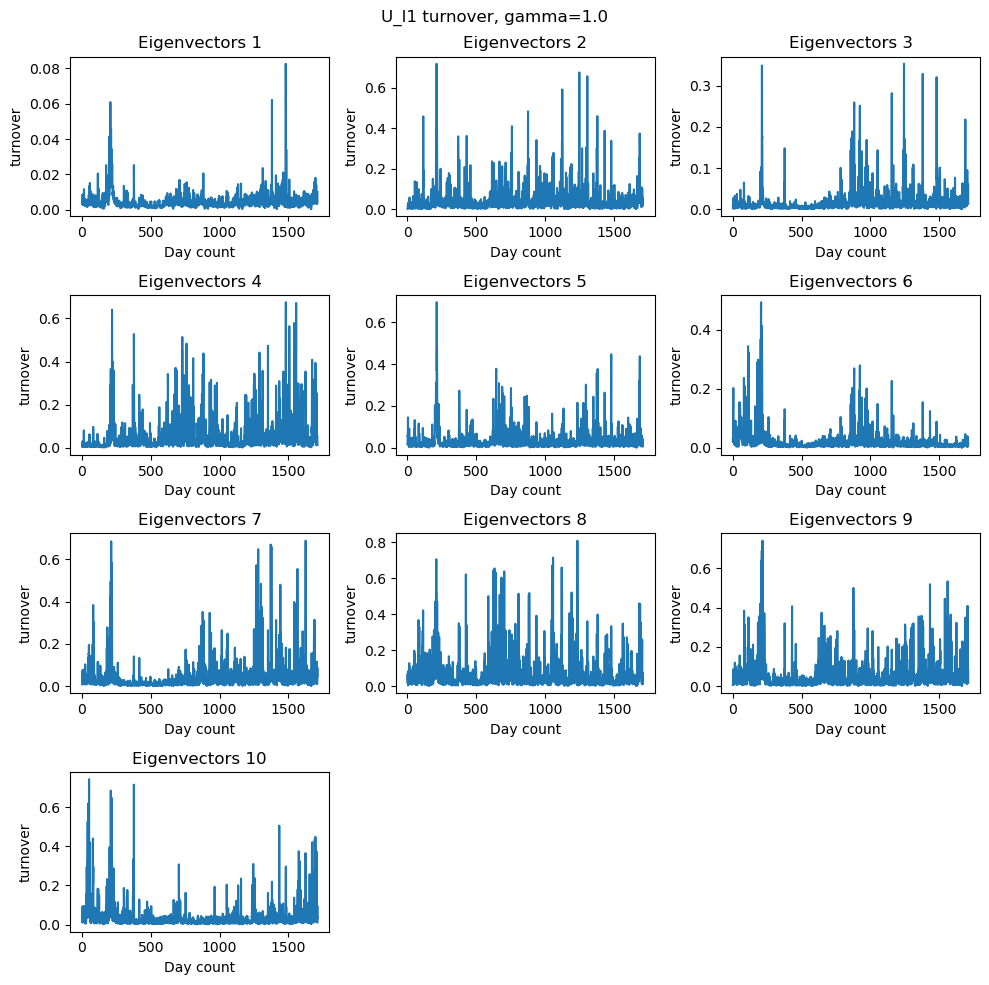

In [ ]:
for metric, factor_turnovers in [list(turnovers.items())[1]]:
    df_plot = pd.DataFrame(factor_turnovers)
    fig, ax = plt.subplots(4, 3, figsize=[10, 10])
    plt.suptitle(f"{metric} turnover, gamma={GAMMA}")
    for k in range(N_FACTORS):
        i, j = k // 3, k % 3
        factor = f"Eigenvectors {k + 1}"
        ax[i, j].set_title(factor)
        ax[i, j].set_xlabel("Day count")
        ax[i, j].set_ylabel("turnover")
        ax[i, j].plot(df_plot[factor])
    for k in range(N_FACTORS, 12):
        ax[k // 3, k % 3].axis("off")
    plt.tight_layout()
    plt.show()


## Optional Save

In [ ]:
if SAVE_OUTPUTS:
    suffix = str(GAMMA).replace(".", "p")
    characteristics.to_parquet(f"{OUTPUT_DIR}/characteristics_gamma_{suffix}.parquet")
    residuals.to_parquet(f"{OUTPUT_DIR}/residuals_gamma_{suffix}.parquet")
    factors.to_parquet(f"{OUTPUT_DIR}/factors_gamma_{suffix}.parquet")
